目标函数
XGBoost 的目标函数由两个部分组成：损失函数和正则化项。
目标函数的表达式为：
$$\mathcal{L}(\theta) = \sum_{i=1}^{n} l(y_i, \hat{y}_i) + \sum_{k=1}^{K} \Omega(f_k)$$
其中：
- $y_i $是真实值
- $\hat{y}_i $是预测值
- $l $是损失函数，通常为均方误差 (MSE) 或对数损失
- $f_k $是第 $k $棵树
- $\Omega $是正则化项，用于控制模型的复杂度
梯度提升
XGBoost 通过逐步添加树来最小化损失函数，每一步都是在前一步的基础上改进预测。
假设我们已经有了 $t-1 $棵树，第 $t $棵树的目标是最小化下述的增量损失函数：
$$\mathcal{L}^{(t)} = \sum_{i=1}^{n} l(y_i, \hat{y}_i^{(t-1)} + f_t(x_i)) + \Omega(f_t)$$
其中：
$\hat{y}_i^{(t-1)} $是前 $t-1 $棵树的预测值
$f_t(x_i) $是第 $t $棵树的预测值
泰勒展开
为了简化目标函数，我们对损失函数进行二阶泰勒展开：
$$\mathcal{L}^{(t)} \approx \sum_{i=1}^{n} \left[ l(y_i, \hat{y}_i^{(t-1)}) + g_i f_t(x_i) + \frac{1}{2} h_i f_t(x_i)^2 \right] + \Omega(f_t)$$
其中：
- $g_i = \frac{\partial l(y_i, \hat{y}_i^{(t-1)})}{\partial \hat{y}_i^{(t-1)}} $是一阶导数（梯度）
- $h_i = \frac{\partial^2 l(y_i, \hat{y}_i^{(t-1)})}{\partial \hat{y}_i^{(t-1)^2}} $是二阶导数（Hessian）
将常数项去掉后，简化为：
$$\mathcal{L}^{(t)} \approx \sum_{i=1}^{n} \left[ g_i f_t(x_i) + \frac{1}{2} h_i f_t(x_i)^2 \right] + \Omega(f_t)$$
树模型和正则化
XGBoost 中每棵树的模型可以表示为：
$$f_t(x) = w_{q(x)}$$
其中：
- $q $是叶子节点的索引函数，将输入 $x $映射到叶子节点 $q(x)$
- $w $是叶子节点的权重<br>
正则化项定义为：
$$\Omega(f) = \gamma T + \frac{1}{2} \lambda \sum_{j=1}^{T} w_j^2$$
其中：
 - $T $是叶子节点的数量
 - $\gamma $和 $\lambda $是正则化参数，控制树的复杂度
最优化目标
将树模型和正则化项代入简化的目标函数：
$$\mathcal{L}^{(t)} = \sum_{i=1}^{n} \left[ g_i w_{q(x_i)} + \frac{1}{2} h_i w_{q(x_i)}^2 \right] + \gamma T + \frac{1}{2} \lambda \sum_{j=1}^{T} w_j^2$$
对同一个叶子节点的样本求和：
$$\mathcal{L}^{(t)} = \sum_{j=1}^{T} \left[ G_j w_j + \frac{1}{2} (H_j + \lambda) w_j^2 \right] + \gamma T$$
其中：
 - $G_j = \sum_{i \in I_j} g_i $是第 $j $个叶子节点的梯度之和
 - $H_j = \sum_{i \in I_j} h_i $是第 $j $个叶子节点的 Hessian 之和
通过对 $w_j $求导并令其为零，得到最优的叶子节点权重：
$$w_j^* = -\frac{G_j}{H_j + \lambda}$$
将最优权重代入目标函数，得到最小化后的目标值：
$$\mathcal{L}^{(t)} = -\frac{1}{2} \sum_{j=1}^{T} \frac{G_j^2}{H_j + \lambda} + \gamma T$$
树的分裂
为了找到最优的分裂点，XGBoost 计算每个候选分裂点的增益：
$$\text{Gain} = \frac{1}{2} \left( \frac{G_L^2}{H_L + \lambda} + \frac{G_R^2}{H_R + \lambda} - \frac{(G_L + G_R)^2}{H_L + H_R + \lambda} \right) - \gamma$$
其中：
 - $G_L $和 $H_L $分别是左子节点的梯度和 Hessian 之和
 - $G_R $和 $H_R $分别是右子节点的梯度和 Hessian 之和
选择增益最大的分裂点进行分裂。<br>
算法流程<br>
XGBoost 的整体算法流程：
1. 初始化： 初始化预测值 $\hat{y}_i^{(0)} $为一个常数值（通常为目标值的平均值）。
2. 迭代： 对于每一棵树 $t $，进行以下步骤：
a. 计算梯度和 Hessian： 计算每个样本的梯度 $g_i $和 Hessian $h_i $。
b. 构建树： 逐层分裂节点，计算每个候选分裂点的增益，选择增益最大的分裂点，直至达到预设的叶子节点数或增益小于阈值。
c. 计算叶子节点权重： 根据梯度和 Hessian 计算每个叶子节点的权重 $w_j^* $。
3. 更新预测值： 更新每个样本的预测值 $\hat{y}_i^{(t)} = \hat{y}_i^{(t-1)} + f_t(x_i) $。
通过以上步骤，不断迭代构建新的树，每棵树都在前一棵树的基础上改进，最终得到一个强大的模型。

In [5]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

# 导入数据集
train_data = pd.read_csv('../2.分类/Dataset/3.housing.csv')
train_data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [6]:
# 检查缺失值
train_data.isnull().sum()  # 快速查看每列缺失值数量

# 填充缺失值
train_data['total_bedrooms'] = train_data['total_bedrooms'].fillna(train_data['total_bedrooms'].median())

# 创建特征
train_data['rooms_per_household'] = train_data['total_rooms'] / train_data['households']
train_data['bedrooms_per_room'] = train_data['total_bedrooms'] / train_data['total_rooms']
train_data['population_per_household'] = train_data['population'] / train_data['households']

# 将分类特征转换为数值
train_data = pd.get_dummies(train_data, columns=['ocean_proximity'], drop_first=True)  # 删除第一个类别生成的虚拟变量列，以避免多重共线性（Multicollinearity）问题。

# 定义特征和标签
X = train_data.drop('median_house_value', axis=1)
y = train_data['median_house_value']

In [7]:
# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# 创建XGBoost回归模型
xgb_reg = xgb.XGBRegressor()

# 训练模型
xgb_reg.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

RMSE: 47501.7157


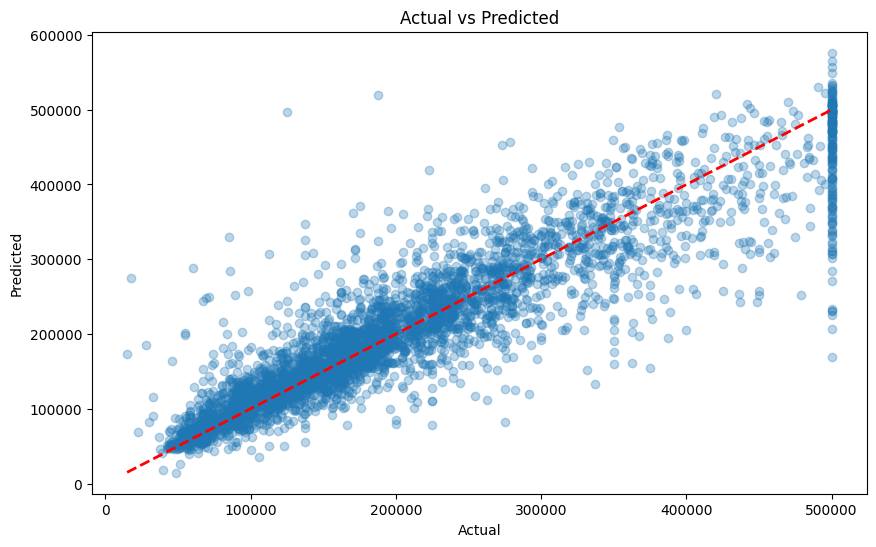

In [9]:
# 预测
y_pred = xgb_reg.predict(X_test)

# 均方根误差
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse:.4f}")

# 可视化实际值与预测值的关系
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}
Optimized RMSE: 44949.2620


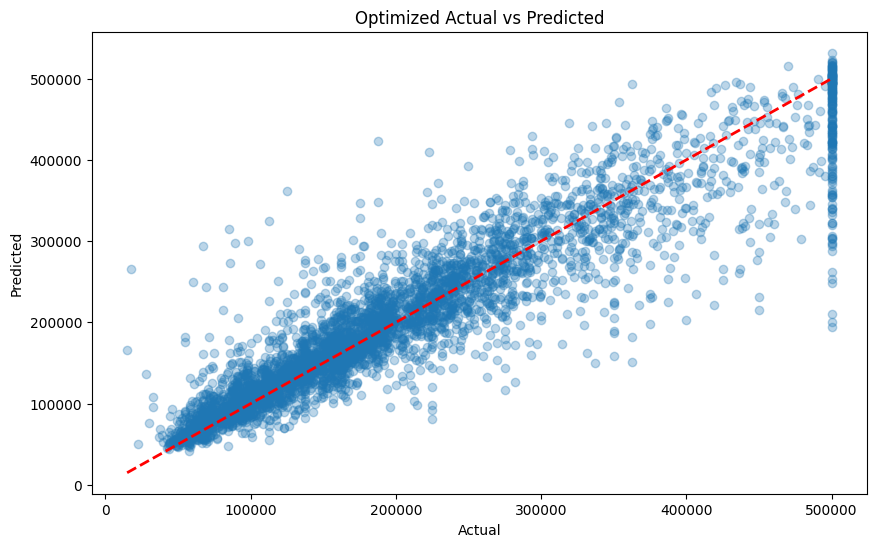

In [10]:
# 参数网格
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 1],  # 在训练每一棵决策树时，随机抽取多大比例的训练样本。
    'colsample_bytree': [0.8, 1]
}

# 网格搜索
grid_search = GridSearchCV(estimator=xgb_reg, param_grid=param_grid, scoring='neg_mean_squared_error', cv=3, verbose=1)
grid_search.fit(X_train, y_train)

# 最优参数
best_params = grid_search.best_params_
print(f"Best parameters: {best_params}")

# 使用最优参数训练模型
xgb_reg_optimized = xgb.XGBRegressor(**best_params)  # 字典解包操作
xgb_reg_optimized.fit(X_train, y_train)

# 预测
y_pred_optimized = xgb_reg_optimized.predict(X_test)

# 均方根误差
rmse_optimized = np.sqrt(mean_squared_error(y_test, y_pred_optimized))
print(f"Optimized RMSE: {rmse_optimized:.4f}")

# 可视化实际值与预测值的关系（优化后）
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_optimized, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Optimized Actual vs Predicted')
plt.show()

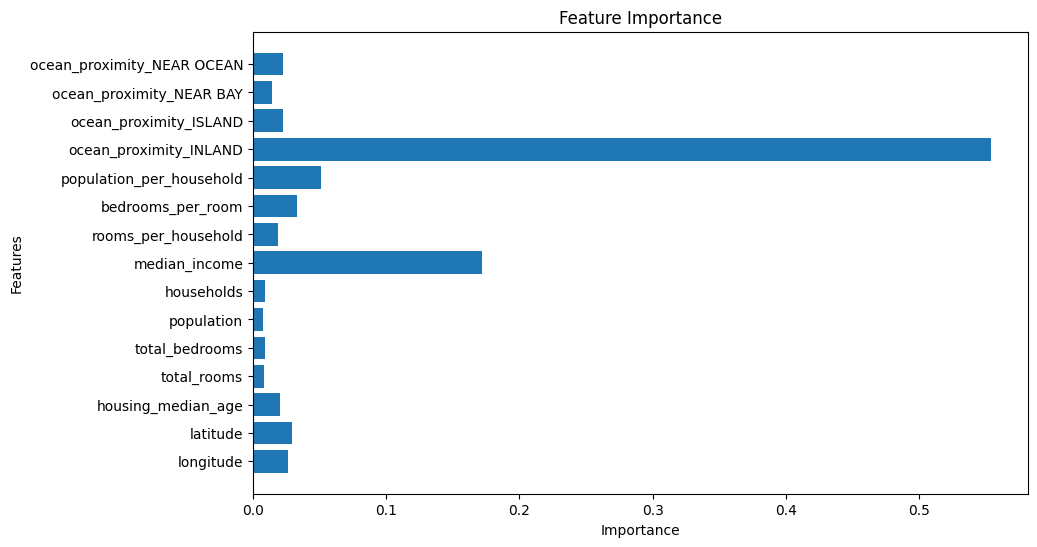

In [11]:
# 特征重要性
importance = xgb_reg_optimized.feature_importances_
features = X.columns

# 可视化
plt.figure(figsize=(10, 6))
plt.barh(features, importance)
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance')
plt.show()

#### 使用经验准则见于 飞书/3.集成/9.XGBClassifier.ipynb